In [ ]:
"""
Gene-to-m/z Spatial Pattern Matching Pipeline V10
================================================

KEY PARAMETERS:
- RNA (Visium): ~55 μm pixel size, hexagonal grid, 6 neighbors
- MSI: 60 μm pixel size, Cartesian grid, 8 neighbors
- RNA needs 180° rotation to align with MSI (check if you need rotaion or not)

APPROACH:
Since pixel sizes are similar (55 vs 60 μm), we use:
1. Coordinate-based matching (with rotation + scaling)
2. Resolution-invariant descriptors (for robustness)
3. Cross-Modal Transformers with learned positional encodings (NEW)

The Cross-Modal Transformer learns to align RNA and MSI modalities
in a shared embedding space using attention mechanisms.

Author: V10 - Added Cross-Modal Transformers with Learned Positional Encodings
"""

import numpy as np
import scanpy as sc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, GATv2Conv
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors
from scipy.stats import pearsonr, spearmanr
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Optional
import pandas as pd
import os
import warnings
from collections import defaultdict
from dataclasses import dataclass
import pickle
import math

warnings.filterwarnings('ignore')


# =============================================================================
# DATA CONFIGURATION
# =============================================================================

RNA_PIXEL_SIZE = 55  # μm (Visium)
MSI_PIXEL_SIZE = 60  # μm
USE_GATV2 = True  # Use GATv2 (recommended) or GAT (set to False)


MSI_INPUT_FOLDER = "/home/ajarrah/PhD_Thesis/chapter_4/dummy_data_8/msi/"
MSI_SAMPLE_FILES = [
    "halfbrain_yc_1_filtered_common.h5ad", "halfbrain_yc_2_filtered_common.h5ad",
    "halfbrain_yc_3_filtered_common.h5ad", "halfbrain_yc_4_filtered_common.h5ad",
    "halfbrain_yad_1_filtered_common.h5ad", "halfbrain_yad_2_filtered_common.h5ad",
    "halfbrain_yad_3_filtered_common.h5ad", "halfbrain_yad_4_filtered_common.h5ad",
    "halfbrain_ac_1_filtered_common.h5ad", "halfbrain_ac_2_filtered_common.h5ad",
    "halfbrain_ac_3_filtered_common.h5ad", "halfbrain_ac_4_filtered_common.h5ad",
    "halfbrain_aad_1_filtered_common.h5ad", "halfbrain_aad_2_filtered_common.h5ad",
    "halfbrain_aad_3_filtered_common.h5ad", "halfbrain_aad_4_filtered_common.h5ad"
]
MSI_SAMPLE_IDS = [
    "YC_1", "YC_2", "YC_3", "YC_4",
    "YAD_1", "YAD_2", "YAD_3", "YAD_4",
    "AC_1", "AC_2", "AC_3", "AC_4",
    "AAD_1", "AAD_2", "AAD_3", "AAD_4"
]

RNA_INPUT_FOLDER = "/home/ajarrah/PhD_Thesis/chapter_4/dummy_data_8/rna/"
RNA_SAMPLE_FILES = [
    "YC_1.h5ad", "YC_2.h5ad", "YC_3.h5ad", "YC_4.h5ad",
    "YAD_1.h5ad", "YAD_2.h5ad", "YAD_3.h5ad", "YAD_4.h5ad",
    "AC_1.h5ad", "AC_2.h5ad", "AC_3.h5ad", "AC_4.h5ad",
    "AAD_1.h5ad", "AAD_2.h5ad", "AAD_3.h5ad", "AAD_4.h5ad"
]
RNA_SAMPLE_IDS = [
    "YC_1", "YC_2", "YC_3", "YC_4",
    "YAD_1", "YAD_2", "YAD_3", "YAD_4",
    "AC_1", "AC_2", "AC_3", "AC_4",
    "AAD_1", "AAD_2", "AAD_3", "AAD_4"
]

AAD_TARGET_GENES = ['Gene_Gradient_X', 'Gene_Radial_Center', 'Gene_Blob_TopRight', 'Gene_Stripes_Vertical']


In [ ]:


# =============================================================================
# COORDINATE TRANSFORMATION
# =============================================================================

def rotate_180(coords: np.ndarray) -> np.ndarray:
    """Rotate coordinates 180° around centroid"""
    center = coords.mean(axis=0)
    return 2 * center - coords


def align_rna_to_msi(rna_coords: np.ndarray, msi_coords: np.ndarray) -> np.ndarray:
    """Align RNA coordinates to MSI coordinate system with 180° rotation and scaling"""
    rotated = rotate_180(rna_coords)
    
    rna_min, rna_max = rotated.min(axis=0), rotated.max(axis=0)
    msi_min, msi_max = msi_coords.min(axis=0), msi_coords.max(axis=0)
    
    rna_range = rna_max - rna_min
    msi_range = msi_max - msi_min
    scale = msi_range / (rna_range + 1e-8)
    
    return (rotated - rna_min) * scale + msi_min


# =============================================================================
# RESOLUTION-INVARIANT DESCRIPTORS
# =============================================================================

def compute_value_histogram(values: np.ndarray, n_bins: int = 50) -> np.ndarray:
    """Value distribution histogram"""
    hist, _ = np.histogram(values, bins=n_bins, density=True)
    return hist / (hist.sum() + 1e-8)


def compute_spatial_histogram(coords: np.ndarray, values: np.ndarray, n_bins: int = 10) -> np.ndarray:
    """2D spatial histogram (normalized coordinates)"""
    norm = (coords - coords.min(axis=0)) / (coords.max(axis=0) - coords.min(axis=0) + 1e-8)
    
    hist = np.zeros((n_bins, n_bins))
    counts = np.zeros((n_bins, n_bins))
    
    for i in range(len(coords)):
        x_bin = min(int(norm[i, 0] * n_bins), n_bins - 1)
        y_bin = min(int(norm[i, 1] * n_bins), n_bins - 1)
        hist[y_bin, x_bin] += values[i]
        counts[y_bin, x_bin] += 1
    
    hist = np.divide(hist, counts, where=counts > 0, out=np.zeros_like(hist))
    
    if hist.max() > hist.min():
        hist = (hist - hist.min()) / (hist.max() - hist.min())
    
    return hist


def compute_radial_profile(coords: np.ndarray, values: np.ndarray, n_rings: int = 10) -> np.ndarray:
    """Radial distribution from centroid"""
    norm = (coords - coords.min(axis=0)) / (coords.max(axis=0) - coords.min(axis=0) + 1e-8)
    centroid = norm.mean(axis=0)
    
    distances = np.linalg.norm(norm - centroid, axis=1)
    max_dist = distances.max()
    
    profile = np.zeros(n_rings)
    counts = np.zeros(n_rings)
    
    for i in range(len(coords)):
        ring = min(int(distances[i] / max_dist * n_rings), n_rings - 1)
        profile[ring] += values[i]
        counts[ring] += 1
    
    profile = np.divide(profile, counts, where=counts > 0, out=np.zeros_like(profile))
    
    if profile.max() > profile.min():
        profile = (profile - profile.min()) / (profile.max() - profile.min())
    
    return profile


def compute_quadrant_stats(coords: np.ndarray, values: np.ndarray, n_div: int = 3) -> np.ndarray:
    """Statistics in spatial quadrants"""
    norm = (coords - coords.min(axis=0)) / (coords.max(axis=0) - coords.min(axis=0) + 1e-8)
    
    stats = []
    for qx in range(n_div):
        for qy in range(n_div):
            x_min, x_max = qx / n_div, (qx + 1) / n_div
            y_min, y_max = qy / n_div, (qy + 1) / n_div
            
            mask = (
                (norm[:, 0] >= x_min) & (norm[:, 0] < x_max) &
                (norm[:, 1] >= y_min) & (norm[:, 1] < y_max)
            )
            
            if mask.sum() > 0:
                q_vals = values[mask]
                stats.extend([np.mean(q_vals), np.std(q_vals)])
            else:
                stats.extend([0, 0])
    
    stats = np.array(stats)
    if stats.max() > stats.min():
        stats = (stats - stats.min()) / (stats.max() - stats.min())
    
    return stats


def compute_morans_i(coords: np.ndarray, values: np.ndarray, k: int = 8) -> float:
    """Moran's I spatial autocorrelation"""
    norm = (coords - coords.min(axis=0)) / (coords.max(axis=0) - coords.min(axis=0) + 1e-8)
    
    nn = NearestNeighbors(n_neighbors=k + 1)
    nn.fit(norm)
    _, indices = nn.kneighbors(norm)
    
    n = len(values)
    mean_val = values.mean()
    denom = np.sum((values - mean_val) ** 2)
    
    if denom == 0:
        return 0
    
    numer = 0
    w_sum = 0
    
    for i in range(n):
        for j in indices[i, 1:]:
            numer += (values[i] - mean_val) * (values[j] - mean_val)
            w_sum += 1
    
    return (n / w_sum) * (numer / denom) if w_sum > 0 else 0


# =============================================================================
# LEARNED POSITIONAL ENCODING
# =============================================================================

class LearnedPositionalEncoding2D(nn.Module):
    """
    Learned 2D positional encoding for spatial coordinates.
    
    Combines learnable embeddings with sinusoidal features for both
    absolute position and relative spatial relationships.
    """
    
    def __init__(self, d_model: int, max_spatial_size: int = 1000, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.max_spatial_size = max_spatial_size
        
        # Learnable position embeddings (grid-based)
        self.x_embedding = nn.Embedding(max_spatial_size, d_model // 2)
        self.y_embedding = nn.Embedding(max_spatial_size, d_model // 2)
        
        # Continuous coordinate projection (for non-grid positions)
        self.coord_projection = nn.Sequential(
            nn.Linear(2, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model)
        )
        
        # Learnable scale parameters for combining embeddings
        self.alpha = nn.Parameter(torch.ones(1) * 0.5)
        self.beta = nn.Parameter(torch.ones(1) * 0.5)
        
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)
        
    def _get_sinusoidal_encoding(self, coords: torch.Tensor) -> torch.Tensor:
        """Generate sinusoidal positional encoding from continuous coordinates"""
        batch_size, n_points, _ = coords.shape
        device = coords.device
        
        # Scale coordinates to [0, 1]
        coords_norm = coords.clone()
        for b in range(batch_size):
            c_min = coords[b].min(dim=0)[0]
            c_max = coords[b].max(dim=0)[0]
            coords_norm[b] = (coords[b] - c_min) / (c_max - c_min + 1e-8)
        
        # Generate frequency bands
        d_half = self.d_model // 4
        freq_bands = torch.exp(
            torch.arange(0, d_half, dtype=torch.float32, device=device) *
            (-math.log(10000.0) / d_half)
        )
        
        # Apply sinusoidal encoding to x and y separately
        x_enc = coords_norm[..., 0:1] * freq_bands  # [B, N, d_half]
        y_enc = coords_norm[..., 1:2] * freq_bands  # [B, N, d_half]
        
        pe = torch.cat([
            torch.sin(x_enc), torch.cos(x_enc),
            torch.sin(y_enc), torch.cos(y_enc)
        ], dim=-1)
        
        return pe
    
    def forward(self, x: torch.Tensor, coords: torch.Tensor) -> torch.Tensor:
        """
        Add positional encoding to input features.
        
        Args:
            x: Input features [batch_size, n_points, d_model]
            coords: Spatial coordinates [batch_size, n_points, 2]
        
        Returns:
            Position-encoded features [batch_size, n_points, d_model]
        """
        # Handle unbatched input
        if x.dim() == 2:
            x = x.unsqueeze(0)
            coords = coords.unsqueeze(0)
            squeeze_output = True
        else:
            squeeze_output = False
        
        batch_size, n_points, _ = x.shape
        device = x.device
        
        # Normalize coordinates to grid indices
        coords_norm = coords.clone()
        for b in range(batch_size):
            c_min = coords[b].min(dim=0)[0]
            c_max = coords[b].max(dim=0)[0]
            coords_norm[b] = (coords[b] - c_min) / (c_max - c_min + 1e-8)
        
        # Get grid indices (clamped to valid range)
        x_idx = (coords_norm[..., 0] * (self.max_spatial_size - 1)).long().clamp(0, self.max_spatial_size - 1)
        y_idx = (coords_norm[..., 1] * (self.max_spatial_size - 1)).long().clamp(0, self.max_spatial_size - 1)
        
        # Learnable grid embeddings
        x_emb = self.x_embedding(x_idx)  # [B, N, d_model//2]
        y_emb = self.y_embedding(y_idx)  # [B, N, d_model//2]
        grid_pe = torch.cat([x_emb, y_emb], dim=-1)  # [B, N, d_model]
        
        # Continuous coordinate projection
        coord_pe = self.coord_projection(coords)  # [B, N, d_model]
        
        # Sinusoidal encoding
        sin_pe = self._get_sinusoidal_encoding(coords)  # [B, N, d_model]
        
        # Combine all positional encodings with learnable weights
        alpha = torch.sigmoid(self.alpha)
        beta = torch.sigmoid(self.beta)
        
        combined_pe = alpha * grid_pe + beta * coord_pe + (1 - alpha - beta).clamp(min=0) * sin_pe
        
        # Add to input and normalize
        output = self.norm(x + self.dropout(combined_pe))
        
        if squeeze_output:
            output = output.squeeze(0)
        
        return output


# =============================================================================
# CROSS-MODAL TRANSFORMER
# =============================================================================

class CrossModalAttention(nn.Module):
    """
    Cross-modal attention layer for aligning RNA and MSI modalities.
    
    Uses multi-head attention where queries come from one modality
    and keys/values come from the other modality.
    """
    
    def __init__(self, d_model: int, n_heads: int = 8, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0
        
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
        
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)
        
    def forward(
        self,
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
        mask: Optional[torch.Tensor] = None
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Cross-modal attention.
        
        Args:
            query: Query tensor [batch, n_query, d_model]
            key: Key tensor [batch, n_key, d_model]
            value: Value tensor [batch, n_key, d_model]
            mask: Optional attention mask
        
        Returns:
            output: Attended features [batch, n_query, d_model]
            attention: Attention weights [batch, n_heads, n_query, n_key]
        """
        batch_size = query.size(0)
        
        # Linear projections
        Q = self.w_q(query).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.w_k(key).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.w_v(value).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        
        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        
        attention = F.softmax(scores, dim=-1)
        attention = self.dropout(attention)
        
        # Apply attention to values
        context = torch.matmul(attention, V)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        
        output = self.w_o(context)
        
        return output, attention


class CrossModalTransformerLayer(nn.Module):
    """
    Single layer of the Cross-Modal Transformer.
    
    Contains:
    - Self-attention within each modality
    - Cross-attention between modalities
    - Feed-forward network
    """
    
    def __init__(self, d_model: int, n_heads: int = 8, d_ff: int = 512, dropout: float = 0.1):
        super().__init__()
        
        # Self-attention
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.self_norm = nn.LayerNorm(d_model)
        
        # Cross-attention
        self.cross_attn = CrossModalAttention(d_model, n_heads, dropout)
        self.cross_norm = nn.LayerNorm(d_model)
        
        # Feed-forward
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )
        self.ff_norm = nn.LayerNorm(d_model)
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(
        self,
        x: torch.Tensor,
        context: torch.Tensor,
        x_coords: Optional[torch.Tensor] = None,
        context_coords: Optional[torch.Tensor] = None
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass through transformer layer.
        
        Args:
            x: Input features from source modality [batch, n_source, d_model]
            context: Features from target modality [batch, n_target, d_model]
            x_coords: Optional spatial coordinates for source
            context_coords: Optional spatial coordinates for target
        
        Returns:
            output: Transformed features [batch, n_source, d_model]
            cross_attention: Cross-modal attention weights
        """
        # Self-attention
        self_out, _ = self.self_attn(x, x, x)
        x = self.self_norm(x + self.dropout(self_out))
        
        # Cross-attention
        cross_out, cross_attn = self.cross_attn(x, context, context)
        x = self.cross_norm(x + self.dropout(cross_out))
        
        # Feed-forward
        ff_out = self.ff(x)
        x = self.ff_norm(x + ff_out)
        
        return x, cross_attn


class CrossModalTransformer(nn.Module):
    """
    Cross-Modal Transformer for aligning RNA and MSI spatial patterns.
    
    Uses learned positional encodings and bidirectional cross-attention
    to learn a shared embedding space between modalities.
    """
    
    def __init__(
        self,
        d_model: int = 128,
        n_heads: int = 8,
        n_layers: int = 4,
        d_ff: int = 512,
        dropout: float = 0.1,
        max_spatial_size: int = 1000
    ):
        super().__init__()
        
        self.d_model = d_model
        
        # Modality-specific input projections (will be created dynamically)
        self.rna_projections = nn.ModuleDict()
        self.msi_projections = nn.ModuleDict()
        
        # Learned positional encodings for each modality
        self.rna_pos_enc = LearnedPositionalEncoding2D(d_model, max_spatial_size, dropout)
        self.msi_pos_enc = LearnedPositionalEncoding2D(d_model, max_spatial_size, dropout)
        
        # Modality embeddings (learnable tokens to distinguish RNA vs MSI)
        self.rna_modality_emb = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.msi_modality_emb = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        
        # Transformer layers (RNA → MSI direction)
        self.rna_to_msi_layers = nn.ModuleList([
            CrossModalTransformerLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        
        # Transformer layers (MSI → RNA direction)
        self.msi_to_rna_layers = nn.ModuleList([
            CrossModalTransformerLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        
        # Global pooling attention
        self.pool_attention = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.Tanh(),
            nn.Linear(d_model // 2, 1)
        )
        
        # Output projection to shared embedding space
        self.output_proj = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model)
        )
        
    def _get_projection(self, dim: int, modality: str) -> nn.Module:
        """Get or create input projection for given dimension"""
        key = str(dim)
        projections = self.rna_projections if modality == 'rna' else self.msi_projections
        
        if key not in projections:
            device = next(self.parameters()).device
            projections[key] = nn.Sequential(
                nn.Linear(dim, self.d_model),
                nn.LayerNorm(self.d_model),
                nn.GELU()
            ).to(device)
        
        return projections[key]
    
    def _global_pool(self, x: torch.Tensor) -> torch.Tensor:
        """Attention-based global pooling"""
        attn_weights = F.softmax(self.pool_attention(x).squeeze(-1), dim=-1)
        return (attn_weights.unsqueeze(-1) * x).sum(dim=-2)
    
    def forward(
        self,
        rna_features: torch.Tensor,
        rna_coords: torch.Tensor,
        msi_features: torch.Tensor,
        msi_coords: torch.Tensor,
        return_squeezed: bool = True
    ) -> Dict[str, torch.Tensor]:
        """
        Forward pass through cross-modal transformer.
        
        Args:
            rna_features: RNA features [batch, n_rna, d_rna] or [n_rna, d_rna]
            rna_coords: RNA spatial coordinates [batch, n_rna, 2] or [n_rna, 2]
            msi_features: MSI features [batch, n_msi, d_msi] or [n_msi, d_msi]
            msi_coords: MSI spatial coordinates [batch, n_msi, 2] or [n_msi, 2]
            return_squeezed: If True and input was unbatched, squeeze output
        
        Returns:
            Dictionary containing:
            - rna_embedding: Global RNA embedding
            - msi_embedding: Global MSI embedding
            - rna_node_embeddings: Per-node RNA embeddings
            - msi_node_embeddings: Per-node MSI embeddings
            - cross_attention_rna_to_msi: Attention weights RNA→MSI
            - cross_attention_msi_to_rna: Attention weights MSI→RNA
            - similarity_score: Cross-modal similarity score
        """
        # Handle unbatched input
        input_was_unbatched = rna_features.dim() == 2
        if input_was_unbatched:
            rna_features = rna_features.unsqueeze(0)
            rna_coords = rna_coords.unsqueeze(0)
            msi_features = msi_features.unsqueeze(0)
            msi_coords = msi_coords.unsqueeze(0)
        
        batch_size = rna_features.size(0)
        
        # Project inputs to common dimension
        rna_proj = self._get_projection(rna_features.size(-1), 'rna')
        msi_proj = self._get_projection(msi_features.size(-1), 'msi')
        
        rna_h = rna_proj(rna_features)
        msi_h = msi_proj(msi_features)
        
        # Add positional encodings
        rna_h = self.rna_pos_enc(rna_h, rna_coords)
        msi_h = self.msi_pos_enc(msi_h, msi_coords)
        
        # Add modality embeddings
        rna_h = rna_h + self.rna_modality_emb.expand(batch_size, rna_h.size(1), -1)
        msi_h = msi_h + self.msi_modality_emb.expand(batch_size, msi_h.size(1), -1)
        
        # Store attention weights
        rna_to_msi_attns = []
        msi_to_rna_attns = []
        
        # Process through transformer layers (bidirectional)
        rna_out = rna_h
        msi_out = msi_h
        
        for rna_layer, msi_layer in zip(self.rna_to_msi_layers, self.msi_to_rna_layers):
            # RNA attends to MSI
            rna_out, rna_attn = rna_layer(rna_out, msi_out, rna_coords, msi_coords)
            rna_to_msi_attns.append(rna_attn)
            
            # MSI attends to RNA
            msi_out, msi_attn = msi_layer(msi_out, rna_out, msi_coords, rna_coords)
            msi_to_rna_attns.append(msi_attn)
        
        # Global pooling
        rna_global = self._global_pool(rna_out)
        msi_global = self._global_pool(msi_out)
        
        # Combined embedding
        combined = torch.cat([rna_global, msi_global], dim=-1)
        shared_embedding = self.output_proj(combined)
        
        # Compute similarity score
        rna_norm = F.normalize(rna_global, p=2, dim=-1)
        msi_norm = F.normalize(msi_global, p=2, dim=-1)
        similarity = (rna_norm * msi_norm).sum(dim=-1)
        
        outputs = {
            'rna_embedding': rna_global,
            'msi_embedding': msi_global,
            'shared_embedding': shared_embedding,
            'rna_node_embeddings': rna_out,
            'msi_node_embeddings': msi_out,
            'cross_attention_rna_to_msi': torch.stack(rna_to_msi_attns),
            'cross_attention_msi_to_rna': torch.stack(msi_to_rna_attns),
            'similarity_score': similarity
        }
        
        # Only squeeze if input was unbatched AND caller wants squeezed output
        if input_was_unbatched and return_squeezed:
            for key in ['rna_node_embeddings', 'msi_node_embeddings', 
                        'cross_attention_rna_to_msi', 'cross_attention_msi_to_rna']:
                if key in outputs and isinstance(outputs[key], torch.Tensor):
                    if outputs[key].dim() > 0 and outputs[key].size(0) == 1:
                        outputs[key] = outputs[key].squeeze(0)
        
        return outputs


class CrossModalContrastiveLoss(nn.Module):
    """
    Contrastive loss for training the Cross-Modal Transformer.
    
    Encourages matching RNA-MSI pairs to have similar embeddings
    while pushing non-matching pairs apart.
    """
    
    def __init__(self, temperature: float = 0.07, margin: float = 0.5):
        super().__init__()
        self.temperature = temperature
        self.margin = margin
        
    def forward(
        self,
        rna_embeddings: torch.Tensor,
        msi_embeddings: torch.Tensor,
        labels: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        """
        Compute contrastive loss.
        
        Args:
            rna_embeddings: RNA embeddings [batch, d_model]
            msi_embeddings: MSI embeddings [batch, d_model]
            labels: Optional matching labels (1 for match, 0 for non-match)
        
        Returns:
            Contrastive loss value
        """
        # Ensure 2D tensors
        if rna_embeddings.dim() == 1:
            rna_embeddings = rna_embeddings.unsqueeze(0)
        if msi_embeddings.dim() == 1:
            msi_embeddings = msi_embeddings.unsqueeze(0)
        
        batch_size = rna_embeddings.size(0)
        
        # Normalize embeddings
        rna_norm = F.normalize(rna_embeddings, p=2, dim=-1)
        msi_norm = F.normalize(msi_embeddings, p=2, dim=-1)
        
        # For single sample, use cosine similarity loss directly
        if batch_size == 1:
            # Maximize similarity for matching pairs
            similarity = (rna_norm * msi_norm).sum(dim=-1)
            loss = 1 - similarity.mean()
            return loss
        
        # For batch, compute similarity matrix
        similarity = torch.matmul(rna_norm, msi_norm.T) / self.temperature
        
        if labels is None:
            # Assume diagonal elements are positive pairs
            labels = torch.eye(batch_size, device=rna_embeddings.device)
        
        # InfoNCE loss
        log_softmax = F.log_softmax(similarity, dim=-1)
        loss = -(labels * log_softmax).sum(dim=-1).mean()
        
        return loss


# =============================================================================
# SPATIAL SIGNATURE (EXTENDED)
# =============================================================================

@dataclass
class SpatialSignature:
    """Complete spatial signature with transformer embeddings"""
    sample_id: str
    feature_name: str
    feature_type: str
    
    # GNN embeddings
    global_embedding: np.ndarray
    node_embeddings: np.ndarray
    node_importance: np.ndarray
    
    # Cross-Modal Transformer embeddings (NEW)
    transformer_embedding: Optional[np.ndarray] = None
    transformer_node_embeddings: Optional[np.ndarray] = None
    
    # Descriptors
    value_histogram: np.ndarray = None
    spatial_histogram: np.ndarray = None
    radial_profile: np.ndarray = None
    quadrant_stats: np.ndarray = None
    morans_i: float = 0.0
    
    # Raw data
    coordinates: np.ndarray = None
    raw_values: np.ndarray = None
    
    # Aligned coordinates
    aligned_coordinates: Optional[np.ndarray] = None


# =============================================================================
# GNN MODEL
# =============================================================================

class SpatialGNN(nn.Module):
    """
    Spatial GNN for embeddings using GATv2.
    
    Why GATv2 over GAT for spatial transcriptomics/MSI:
    ─────────────────────────────────────────────────────
    1. DYNAMIC ATTENTION: GATv2 computes attention AFTER combining query and key,
       making it more expressive for capturing complex spatial relationships.
       GAT uses "static attention" where the ranking of attention scores is 
       fixed regardless of the query node.
    
    2. BETTER FOR HETEROGENEOUS PATTERNS: Your data has varying spatial patterns
       (some genes cluster in specific regions, others are diffuse). GATv2 can
       adapt attention dynamically based on both source AND target node features.
    
    3. PROVEN FOR SPATIAL DATA: GATv2 has shown superior performance in spatial
       omics tasks where local context matters (like your gene-metabolite matching).
    
    4. THEORETICAL GUARANTEE: GATv2 is strictly more expressive than GAT - any
       function GAT can learn, GATv2 can also learn, but not vice versa.
    
    Reference: Brody et al. "How Attentive are Graph Attention Networks?" ICLR 2022
    """
    
    def __init__(
        self,
        input_dim: int = None,
        hidden_dim: int = 128,
        embedding_dim: int = 64,
        num_heads: int = 4,
        num_layers: int = 3,
        projection_dim: int = 64,
        use_gatv2: bool = None  # If None, uses global USE_GATV2 setting
    ):
        super().__init__()
        
        self.projection_dim = projection_dim
        self.use_gatv2 = use_gatv2 if use_gatv2 is not None else USE_GATV2
        self.input_projections = nn.ModuleDict()
        
        if input_dim is not None:
            self.input_projections[str(input_dim)] = nn.Sequential(
                nn.Linear(input_dim, projection_dim),
                nn.LayerNorm(projection_dim),
                nn.GELU()
            )
        
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        
        # Choose between GAT and GATv2
        ConvClass = GATv2Conv if use_gatv2 else GATConv
        
        self.convs.append(ConvClass(projection_dim, hidden_dim // num_heads,
                                    heads=num_heads, concat=True, dropout=0.1))
        self.norms.append(nn.LayerNorm(hidden_dim))
        
        for _ in range(num_layers - 2):
            self.convs.append(ConvClass(hidden_dim, hidden_dim // num_heads,
                                        heads=num_heads, concat=True, dropout=0.1))
            self.norms.append(nn.LayerNorm(hidden_dim))
        
        self.convs.append(ConvClass(hidden_dim, embedding_dim, heads=1, concat=False, dropout=0.1))
        self.norms.append(nn.LayerNorm(embedding_dim))
        
        self.importance_head = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid()
        )
        
        self.pool_attention = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, projection_dim)
        )
    
    def _get_projection(self, dim):
        key = str(dim)
        if key not in self.input_projections:
            device = next(self.parameters()).device
            self.input_projections[key] = nn.Sequential(
                nn.Linear(dim, self.projection_dim),
                nn.LayerNorm(self.projection_dim),
                nn.GELU()
            ).to(device)
        return self.input_projections[key]
    
    def forward(self, x, edge_index, bio_importance=None):
        h_input = self._get_projection(x.size(1))(x)
        
        h = h_input
        for conv, norm in zip(self.convs, self.norms):
            h = conv(h, edge_index)
            h = norm(h)
            h = F.gelu(h)
        
        node_embeddings = h
        
        learned_imp = self.importance_head(node_embeddings).squeeze(-1)
        if bio_importance is not None:
            node_importance = 0.5 * learned_imp + 0.5 * bio_importance
        else:
            node_importance = learned_imp
        node_importance = node_importance / (node_importance.max() + 1e-8)
        
        weight = node_importance / (node_importance.sum() + 1e-8) * x.size(0)
        weighted_emb = node_embeddings * weight.unsqueeze(-1)
        
        attn = F.softmax(self.pool_attention(node_embeddings).squeeze(-1), dim=0)
        global_emb = (attn.unsqueeze(-1) * weighted_emb).sum(dim=0)
        
        reconstructed = self.decoder(node_embeddings)
        
        return {
            'node_embeddings': node_embeddings,
            'global_embedding': global_emb,
            'node_importance': node_importance,
            'reconstructed': reconstructed,
            'h_input': h_input
        }


class SpatialLoss(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, output, edge_index):
        recon = F.mse_loss(output['reconstructed'], output['h_input'])
        src, dst = edge_index[0], edge_index[1]
        smooth = ((output['node_embeddings'][src] - output['node_embeddings'][dst]) ** 2).mean()
        return recon + 0.3 * smooth


# =============================================================================
# SIMILARITY COMPUTATION (EXTENDED)
# =============================================================================

def compute_coordinate_based_similarity(gene_sig: SpatialSignature, mz_sig: SpatialSignature, grid_res: int = 50) -> dict:
    """Compute similarity using aligned coordinates"""
    gene_coords = gene_sig.aligned_coordinates if gene_sig.aligned_coordinates is not None else gene_sig.coordinates
    mz_coords = mz_sig.coordinates
    
    x_min = min(gene_coords[:, 0].min(), mz_coords[:, 0].min())
    x_max = max(gene_coords[:, 0].max(), mz_coords[:, 0].max())
    y_min = min(gene_coords[:, 1].min(), mz_coords[:, 1].min())
    y_max = max(gene_coords[:, 1].max(), mz_coords[:, 1].max())
    
    grid_x, grid_y = np.meshgrid(
        np.linspace(x_min, x_max, grid_res),
        np.linspace(y_min, y_max, grid_res)
    )
    
    gene_grid = griddata(gene_coords, gene_sig.raw_values, (grid_x, grid_y), method='linear')
    mz_grid = griddata(mz_coords, mz_sig.raw_values, (grid_x, grid_y), method='linear')
    
    gene_imp_grid = griddata(gene_coords, gene_sig.node_importance, (grid_x, grid_y), method='linear')
    mz_imp_grid = griddata(mz_coords, mz_sig.node_importance, (grid_x, grid_y), method='linear')
    
    mask = ~(np.isnan(gene_grid) | np.isnan(mz_grid))
    if mask.sum() > 10:
        value_corr, _ = pearsonr(gene_grid[mask], mz_grid[mask])
        value_corr = value_corr if not np.isnan(value_corr) else 0
    else:
        value_corr = 0
    
    mask_imp = ~(np.isnan(gene_imp_grid) | np.isnan(mz_imp_grid))
    if mask_imp.sum() > 0:
        g_imp = gene_imp_grid.copy()
        m_imp = mz_imp_grid.copy()
        g_imp[np.isnan(g_imp)] = 0
        m_imp[np.isnan(m_imp)] = 0
        
        g_imp = g_imp / (g_imp.max() + 1e-8)
        m_imp = m_imp / (m_imp.max() + 1e-8)
        
        intersection = np.minimum(g_imp, m_imp).sum()
        union = np.maximum(g_imp, m_imp).sum()
        importance_iou = intersection / (union + 1e-8)
        
        imp_corr, _ = pearsonr(g_imp[mask_imp], m_imp[mask_imp])
        imp_corr = imp_corr if not np.isnan(imp_corr) else 0
    else:
        importance_iou = 0
        imp_corr = 0
    
    return {
        'value_correlation': value_corr,
        'importance_iou': importance_iou,
        'importance_correlation': imp_corr
    }


def compute_descriptor_similarity(gene_sig: SpatialSignature, mz_sig: SpatialSignature) -> dict:
    """Compute similarity using resolution-invariant descriptors"""
    
    g_emb = gene_sig.global_embedding.flatten()
    m_emb = mz_sig.global_embedding.flatten()
    emb_cosine = np.dot(g_emb, m_emb) / (np.linalg.norm(g_emb) * np.linalg.norm(m_emb) + 1e-8)
    
    if gene_sig.value_histogram.std() > 0 and mz_sig.value_histogram.std() > 0:
        val_hist_corr, _ = pearsonr(gene_sig.value_histogram, mz_sig.value_histogram)
        val_hist_corr = val_hist_corr if not np.isnan(val_hist_corr) else 0
    else:
        val_hist_corr = 0
    
    g_spatial = gene_sig.spatial_histogram.flatten()
    m_spatial = mz_sig.spatial_histogram.flatten()
    if g_spatial.std() > 0 and m_spatial.std() > 0:
        spatial_hist_corr, _ = pearsonr(g_spatial, m_spatial)
        spatial_hist_corr = spatial_hist_corr if not np.isnan(spatial_hist_corr) else 0
    else:
        spatial_hist_corr = 0
    
    if gene_sig.radial_profile.std() > 0 and mz_sig.radial_profile.std() > 0:
        radial_corr, _ = pearsonr(gene_sig.radial_profile, mz_sig.radial_profile)
        radial_corr = radial_corr if not np.isnan(radial_corr) else 0
    else:
        radial_corr = 0
    
    if gene_sig.quadrant_stats.std() > 0 and mz_sig.quadrant_stats.std() > 0:
        quad_corr, _ = pearsonr(gene_sig.quadrant_stats, mz_sig.quadrant_stats)
        quad_corr = quad_corr if not np.isnan(quad_corr) else 0
    else:
        quad_corr = 0
    
    morans_diff = abs(gene_sig.morans_i - mz_sig.morans_i)
    morans_sim = 1 / (1 + morans_diff)
    
    return {
        'embedding_cosine': emb_cosine,
        'value_hist_corr': val_hist_corr,
        'spatial_hist_corr': spatial_hist_corr,
        'radial_corr': radial_corr,
        'quadrant_corr': quad_corr,
        'morans_similarity': morans_sim
    }


def compute_transformer_similarity(gene_sig: SpatialSignature, mz_sig: SpatialSignature) -> dict:
    """Compute similarity using Cross-Modal Transformer embeddings"""
    
    if gene_sig.transformer_embedding is None or mz_sig.transformer_embedding is None:
        return {
            'transformer_cosine': 0,
            'transformer_l2_distance': 1.0
        }
    
    g_emb = gene_sig.transformer_embedding.flatten()
    m_emb = mz_sig.transformer_embedding.flatten()
    
    # Cosine similarity
    cosine = np.dot(g_emb, m_emb) / (np.linalg.norm(g_emb) * np.linalg.norm(m_emb) + 1e-8)
    
    # L2 distance (normalized)
    l2_dist = np.linalg.norm(g_emb - m_emb)
    l2_sim = 1 / (1 + l2_dist)
    
    return {
        'transformer_cosine': cosine,
        'transformer_l2_similarity': l2_sim
    }


def compute_combined_score(coord_sim: dict, desc_sim: dict, trans_sim: dict = None) -> float:
    """
    Combined score using coordinate-based, descriptor-based, and transformer-based metrics.
    
    Weights:
    - Coordinate-based (35%): Direct spatial comparison after alignment
    - Descriptor-based (35%): Resolution-invariant for robustness
    - Transformer-based (30%): Learned cross-modal alignment
    """
    # Coordinate-based (35%)
    coord_score = (
        0.15 * max(coord_sim['value_correlation'], 0) +
        0.10 * coord_sim['importance_iou'] +
        0.10 * max(coord_sim['importance_correlation'], 0)
    )
    
    # Descriptor-based (35%)
    desc_score = (
        0.10 * desc_sim['embedding_cosine'] +
        0.08 * max(desc_sim['spatial_hist_corr'], 0) +
        0.08 * max(desc_sim['radial_corr'], 0) +
        0.04 * max(desc_sim['quadrant_corr'], 0) +
        0.03 * desc_sim['morans_similarity'] +
        0.02 * max(desc_sim['value_hist_corr'], 0)
    )
    
    # Transformer-based (30%)
    if trans_sim is not None and trans_sim.get('transformer_cosine', 0) != 0:
        trans_score = (
            0.20 * max(trans_sim['transformer_cosine'], 0) +
            0.10 * trans_sim['transformer_l2_similarity']
        )
    else:
        # Fall back to higher weights for other methods if transformer not available
        coord_score *= (1 / 0.7)
        desc_score *= (1 / 0.7)
        trans_score = 0
    
    return coord_score + desc_score + trans_score


# =============================================================================
# MAIN MATCHER
# =============================================================================

class HybridTransformerMatcher:
    """Hybrid matcher with Cross-Modal Transformer"""
    
    def __init__(
        self,
        output_dir: str = './gene_to_mz_results_v10',
        device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    ):
        self.device = device
        self.output_dir = output_dir
        
        subdirs = ['saliency_maps', 'gene_visualizations', 'match_visualizations',
                   'embeddings', 'training_curves', 'descriptors', 'transformer_attention']
        for subdir in subdirs:
            os.makedirs(os.path.join(output_dir, subdir), exist_ok=True)
        
        self.rna_data = {}
        self.msi_data = {}
        self.rna_model = None
        self.msi_model = None
        self.cross_modal_transformer = None
    
    def load_all_data(self):
        """Load data"""
        print("Loading RNA-seq data...")
        print(f"  Pixel size: {RNA_PIXEL_SIZE} μm (hexagonal)")
        for file, sample_id in zip(RNA_SAMPLE_FILES, RNA_SAMPLE_IDS):
            path = os.path.join(RNA_INPUT_FOLDER, file)
            if os.path.exists(path):
                self.rna_data[sample_id] = sc.read_h5ad(path)
                print(f"  {sample_id}: {self.rna_data[sample_id].shape}")
        
        print(f"\nLoading MSI data...")
        print(f"  Pixel size: {MSI_PIXEL_SIZE} μm (Cartesian)")
        for file, sample_id in zip(MSI_SAMPLE_FILES, MSI_SAMPLE_IDS):
            path = os.path.join(MSI_INPUT_FOLDER, file)
            if os.path.exists(path):
                self.msi_data[sample_id] = sc.read_h5ad(path)
                print(f"  {sample_id}: {self.msi_data[sample_id].shape}")
    
    def build_graph(self, coords, n_neighbors):
        """Build spatial graph"""
        nn = NearestNeighbors(n_neighbors=n_neighbors + 1)
        nn.fit(coords)
        distances, indices = nn.kneighbors(coords)
        
        median_dist = np.median(distances[:, 1])
        max_dist = median_dist * 1.5
        
        edges = set()
        for i in range(len(coords)):
            for j_idx in range(1, n_neighbors + 1):
                if distances[i, j_idx] <= max_dist:
                    j = indices[i, j_idx]
                    edges.add((i, j))
                    edges.add((j, i))
        
        return torch.tensor(list(edges), dtype=torch.long).t().contiguous()
    
    def compute_bio_importance(self, coords, values, k):
        """Biological importance"""
        nn = NearestNeighbors(n_neighbors=k + 1)
        nn.fit(coords)
        _, indices = nn.kneighbors(coords)
        
        local_var = np.array([np.var(values[indices[i, 1:]]) for i in range(len(coords))])
        local_var = (local_var - local_var.min()) / (local_var.max() - local_var.min() + 1e-8)
        
        val_norm = (values - values.min()) / (values.max() - values.min() + 1e-8)
        
        return 0.5 * local_var + 0.5 * val_norm
    
    def prepare_data(self, coords, features, n_neighbors):
        """Prepare graph data"""
        if features.ndim == 1:
            features = features.reshape(-1, 1)
        
        bio_imp = np.zeros(len(coords))
        for col in range(features.shape[1]):
            bio_imp += self.compute_bio_importance(coords, features[:, col], n_neighbors)
        bio_imp /= features.shape[1]
        
        scaler = RobustScaler()
        features_scaled = scaler.fit_transform(features)
        
        edge_index = self.build_graph(coords, n_neighbors)
        
        return Data(x=torch.tensor(features_scaled, dtype=torch.float32), edge_index=edge_index), bio_imp
    
    def train_gnn_model(self, data_dict, bio_dict, model_type, epochs=150, val_split=0.2):
        """Train GNN model with validation tracking"""
        print(f"\nTraining {model_type.upper()} GNN model...")
        print(f"  Architecture: {'GATv2' if USE_GATV2 else 'GAT'}")
        
        # Split into train/val
        all_samples = list(data_dict.keys())
        n_val = max(1, int(len(all_samples) * val_split))
        val_samples = all_samples[-n_val:]
        train_samples = all_samples[:-n_val]
        
        print(f"  Train samples: {len(train_samples)}, Val samples: {len(val_samples)}")
        
        first_data = list(data_dict.values())[0]
        model = SpatialGNN(input_dim=first_data.x.size(1)).to(self.device)
        
        optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)
        loss_fn = SpatialLoss()
        
        train_losses = []
        val_losses = []
        best_val_loss = float('inf')
        best_model_state = None
        
        for epoch in range(epochs):
            # Training
            model.train()
            train_loss = 0
            for sample_id in train_samples:
                data = data_dict[sample_id].to(self.device)
                bio_imp = torch.tensor(bio_dict[sample_id], dtype=torch.float32, device=self.device)
                
                optimizer.zero_grad()
                output = model(data.x, data.edge_index, bio_imp)
                loss = loss_fn(output, data.edge_index)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item()
            
            train_losses.append(train_loss / len(train_samples))
            
            # Validation
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for sample_id in val_samples:
                    data = data_dict[sample_id].to(self.device)
                    bio_imp = torch.tensor(bio_dict[sample_id], dtype=torch.float32, device=self.device)
                    
                    output = model(data.x, data.edge_index, bio_imp)
                    loss = loss_fn(output, data.edge_index)
                    val_loss += loss.item()
            
            val_losses.append(val_loss / len(val_samples))
            scheduler.step(val_losses[-1])
            
            # Save best model
            if val_losses[-1] < best_val_loss:
                best_val_loss = val_losses[-1]
                best_model_state = model.state_dict().copy()
            
            if (epoch + 1) % 30 == 0:
                print(f"  Epoch {epoch+1}/{epochs}, Train: {train_losses[-1]:.4f}, Val: {val_losses[-1]:.4f}")
        
        # Load best model
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
            print(f"  Loaded best model with val loss: {best_val_loss:.4f}")
        
        # Plot train and validation curves
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Train Loss', color='blue')
        plt.plot(val_losses, label='Validation Loss', color='red', linestyle='--')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'{model_type.upper()} GNN Training')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Mark best validation point
        best_epoch = np.argmin(val_losses)
        plt.axvline(x=best_epoch, color='green', linestyle=':', alpha=0.7, label=f'Best Val (epoch {best_epoch})')
        plt.scatter([best_epoch], [val_losses[best_epoch]], color='green', s=100, zorder=5)
        
        plt.legend()
        plt.savefig(os.path.join(self.output_dir, 'training_curves', f'{model_type}_gnn_loss.png'), dpi=150)
        plt.close()
        
        return model
    
    def train_cross_modal_transformer(self, rna_samples, msi_samples, epochs=100, val_split=0.2, batch_size=16):
        """Train Cross-Modal Transformer with Batched Training"""
        print("\nTraining Cross-Modal Transformer (Batched)...")
        
        # Initialize model
        self.cross_modal_transformer = CrossModalTransformer(
            d_model=128, n_heads=8, n_layers=4, d_ff=512, dropout=0.1
        ).to(self.device)
        
        optimizer = torch.optim.AdamW(self.cross_modal_transformer.parameters(), lr=0.0005, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        
        # Loss function
        contrastive_loss = CrossModalContrastiveLoss(temperature=0.07) 
        
        # Split Train/Val
        common_samples = list(set(rna_samples.keys()) & set(msi_samples.keys()))
        n_val = max(1, int(len(common_samples) * val_split))
        val_samples = common_samples[-n_val:]
        train_samples = common_samples[:-n_val]
        
        print(f"  Train samples: {len(train_samples)}, Val samples: {len(val_samples)}")
        print(f"  Batch Size: {batch_size}")

        train_losses = []
        val_losses = []
        best_val_loss = float('inf')
        best_model_state = None
        
        # Parameters for fixed-size subsampling
        N_SPOTS_RNA = 500
        N_SPOTS_MSI = 1000
        N_FEAT = 50

        for epoch in range(epochs):
            self.cross_modal_transformer.train()
            epoch_train_loss = 0
            n_batches = 0  # <--- CRITICAL INITIALIZATION
            
            # Shuffle training samples
            np.random.shuffle(train_samples)
            
            # --- BATCHED TRAINING LOOP ---
            for i in range(0, len(train_samples), batch_size):
                batch_ids = train_samples[i : i + batch_size]
                
                # Skip incomplete batches if they are too small
                if len(batch_ids) < 2: 
                    continue

                # Containers for the batch
                b_rna_feat, b_rna_coord = [], []
                b_msi_feat, b_msi_coord = [], []
                
                for sample_id in batch_ids:
                    # Load and Process RNA
                    rna_adata = self.rna_data[sample_id]
                    rna_coords = np.column_stack([rna_adata.obs['x_um'].values, rna_adata.obs['y_um'].values])
                    
                    # Process MSI
                    msi_adata = self.msi_data[sample_id]
                    msi_coords = np.column_stack([msi_adata.obs['x_um'].values, msi_adata.obs['y_um'].values])
                    
                    # Align RNA
                    rna_coords_aligned = align_rna_to_msi(rna_coords, msi_coords)
                    
                    # Subsample RNA
                    if rna_adata.shape[0] >= N_SPOTS_RNA:
                        idx = np.random.choice(rna_adata.shape[0], N_SPOTS_RNA, replace=False)
                    else:
                        idx = np.random.choice(rna_adata.shape[0], N_SPOTS_RNA, replace=True)
                    
                    feat = rna_adata.X[idx, :N_FEAT]
                    if hasattr(feat, 'toarray'): feat = feat.toarray()
                    feat = RobustScaler().fit_transform(feat)
                    
                    b_rna_feat.append(feat)
                    b_rna_coord.append(rna_coords_aligned[idx])
                    
                    # Subsample MSI
                    if msi_adata.shape[0] >= N_SPOTS_MSI:
                        idx = np.random.choice(msi_adata.shape[0], N_SPOTS_MSI, replace=False)
                    else:
                        idx = np.random.choice(msi_adata.shape[0], N_SPOTS_MSI, replace=True)
                        
                    feat = msi_adata.X[idx, :N_FEAT]
                    if hasattr(feat, 'toarray'): feat = feat.toarray()
                    feat = RobustScaler().fit_transform(feat)
                    
                    b_msi_feat.append(feat)
                    b_msi_coord.append(msi_coords[idx])

                # Stack into Tensors
                rna_feat_t = torch.tensor(np.stack(b_rna_feat), dtype=torch.float32, device=self.device)
                rna_coord_t = torch.tensor(np.stack(b_rna_coord), dtype=torch.float32, device=self.device)
                msi_feat_t = torch.tensor(np.stack(b_msi_feat), dtype=torch.float32, device=self.device)
                msi_coord_t = torch.tensor(np.stack(b_msi_coord), dtype=torch.float32, device=self.device)

                # Forward Pass
                optimizer.zero_grad()
                outputs = self.cross_modal_transformer(
                    rna_feat_t, rna_coord_t, msi_feat_t, msi_coord_t, return_squeezed=False
                )
                
                # Compute Loss
                loss = contrastive_loss(outputs['rna_embedding'], outputs['msi_embedding'])
                
                # Add alignment loss (reduced weight)
                alignment_loss = 1 - outputs['similarity_score'].mean()
                loss = loss + 0.1 * alignment_loss
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.cross_modal_transformer.parameters(), 1.0)
                optimizer.step()
                
                epoch_train_loss += loss.item()
                n_batches += 1  # <--- Error happened here; requires n_batches=0 above
            
            scheduler.step()
            avg_train_loss = epoch_train_loss / max(n_batches, 1)
            train_losses.append(avg_train_loss)
            
            # --- VALIDATION LOOP (Simplified) ---
            self.cross_modal_transformer.eval()
            epoch_val_loss = 0
            n_val_batches = 0
            
            with torch.no_grad():
                for sample_id in val_samples:
                    # Load Data (Standard, Single Sample for Validation metrics)
                    rna_adata = self.rna_data[sample_id]
                    msi_adata = self.msi_data[sample_id]
                    
                    rna_coords = np.column_stack([rna_adata.obs['x_um'].values, rna_adata.obs['y_um'].values])
                    msi_coords = np.column_stack([msi_adata.obs['x_um'].values, msi_adata.obs['y_um'].values])
                    rna_coords_aligned = align_rna_to_msi(rna_coords, msi_coords)
                    
                    # Subsample
                    idx_rna = np.random.choice(rna_adata.shape[0], min(N_SPOTS_RNA, rna_adata.shape[0]), replace=False)
                    idx_msi = np.random.choice(msi_adata.shape[0], min(N_SPOTS_MSI, msi_adata.shape[0]), replace=False)
                    
                    feat_rna = rna_adata.X[idx_rna, :N_FEAT]
                    if hasattr(feat_rna, 'toarray'): feat_rna = feat_rna.toarray()
                    feat_rna = RobustScaler().fit_transform(feat_rna)
                    
                    feat_msi = msi_adata.X[idx_msi, :N_FEAT]
                    if hasattr(feat_msi, 'toarray'): feat_msi = feat_msi.toarray()
                    feat_msi = RobustScaler().fit_transform(feat_msi)
                    
                    # Tensorize (Add Batch Dim)
                    r_f = torch.tensor(feat_rna, dtype=torch.float32, device=self.device).unsqueeze(0)
                    r_c = torch.tensor(rna_coords_aligned[idx_rna], dtype=torch.float32, device=self.device).unsqueeze(0)
                    m_f = torch.tensor(feat_msi, dtype=torch.float32, device=self.device).unsqueeze(0)
                    m_c = torch.tensor(msi_coords[idx_msi], dtype=torch.float32, device=self.device).unsqueeze(0)
                    
                    out = self.cross_modal_transformer(r_f, r_c, m_f, m_c, return_squeezed=False)
                    
                    # Loss
                    v_loss = contrastive_loss(out['rna_embedding'], out['msi_embedding'])
                    v_loss += 0.1 * (1 - out['similarity_score'].mean())
                    
                    epoch_val_loss += v_loss.item()
                    n_val_batches += 1

            avg_val_loss = epoch_val_loss / max(n_val_batches, 1)
            val_losses.append(avg_val_loss)
            
            # Save Best
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                best_model_state = self.cross_modal_transformer.state_dict().copy()
            
            if (epoch + 1) % 20 == 0:
                print(f"  Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Restore Best
        if best_model_state:
            self.cross_modal_transformer.load_state_dict(best_model_state)
            print(f"  Loaded best model with Val Loss: {best_val_loss:.4f}")
        
        # Plot train and validation curves
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Train Loss', color='blue')
        plt.plot(val_losses, label='Validation Loss', color='red', linestyle='--')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Cross-Modal Transformer Training')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Mark best validation point
        best_epoch = np.argmin(val_losses)
        plt.axvline(x=best_epoch, color='green', linestyle=':', alpha=0.7)
        plt.scatter([best_epoch], [val_losses[best_epoch]], color='green', s=100, zorder=5, label=f'Best Val (epoch {best_epoch})')
        
        plt.legend()
        plt.savefig(os.path.join(self.output_dir, 'training_curves', 'transformer_loss.png'), dpi=150)
        plt.close()
        
        print(f"  Final train loss: {train_losses[-1]:.4f}, Final val loss: {val_losses[-1]:.4f}")
    
    def extract_signature(
        self,
        coords: np.ndarray,
        values: np.ndarray,
        sample_id: str,
        feature_name: str,
        feature_type: str,
        model: SpatialGNN,
        n_neighbors: int,
        msi_coords: Optional[np.ndarray] = None
    ) -> SpatialSignature:
        """Extract signature with all descriptors"""
        
        bio_imp = self.compute_bio_importance(coords, values, n_neighbors)
        data, _ = self.prepare_data(coords, values, n_neighbors)
        data = data.to(self.device)
        bio_tensor = torch.tensor(bio_imp, dtype=torch.float32, device=self.device)
        
        model.eval()
        with torch.no_grad():
            output = model(data.x, data.edge_index, bio_tensor)
        
        val_hist = compute_value_histogram(values)
        spatial_hist = compute_spatial_histogram(coords, values)
        radial = compute_radial_profile(coords, values)
        quadrant = compute_quadrant_stats(coords, values)
        morans = compute_morans_i(coords, values, n_neighbors)
        
        aligned = None
        if feature_type == 'gene' and msi_coords is not None:
            aligned = align_rna_to_msi(coords, msi_coords)
        
        return SpatialSignature(
            sample_id=sample_id,
            feature_name=feature_name,
            feature_type=feature_type,
            global_embedding=output['global_embedding'].cpu().numpy(),
            node_embeddings=output['node_embeddings'].cpu().numpy(),
            node_importance=output['node_importance'].cpu().numpy(),
            transformer_embedding=None,
            transformer_node_embeddings=None,
            value_histogram=val_hist,
            spatial_histogram=spatial_hist,
            radial_profile=radial,
            quadrant_stats=quadrant,
            morans_i=morans,
            coordinates=coords,
            raw_values=values,
            aligned_coordinates=aligned
        )
    
    def compute_transformer_embeddings(
        self,
        gene_sig: SpatialSignature,
        mz_sig: SpatialSignature
    ) -> Tuple[np.ndarray, np.ndarray, dict]:
        """Compute Cross-Modal Transformer embeddings for a gene-mz pair"""
        
        if self.cross_modal_transformer is None:
            return None, None, {}
        
        self.cross_modal_transformer.eval()
        
        # Use aligned coordinates for gene
        gene_coords = gene_sig.aligned_coordinates if gene_sig.aligned_coordinates is not None else gene_sig.coordinates
        mz_coords = mz_sig.coordinates
        
        # Prepare features
        gene_values = gene_sig.raw_values.reshape(-1, 1)
        mz_values = mz_sig.raw_values.reshape(-1, 1)
        
        scaler = RobustScaler()
        gene_scaled = scaler.fit_transform(gene_values)
        mz_scaled = scaler.fit_transform(mz_values)
        
        # Convert to tensors
        gene_feat_t = torch.tensor(gene_scaled, dtype=torch.float32, device=self.device).unsqueeze(0)
        gene_coord_t = torch.tensor(gene_coords, dtype=torch.float32, device=self.device).unsqueeze(0)
        mz_feat_t = torch.tensor(mz_scaled, dtype=torch.float32, device=self.device).unsqueeze(0)
        mz_coord_t = torch.tensor(mz_coords, dtype=torch.float32, device=self.device).unsqueeze(0)
        
        with torch.no_grad():
            outputs = self.cross_modal_transformer(gene_feat_t, gene_coord_t, mz_feat_t, mz_coord_t)
        
        attention_info = {
            'rna_to_msi': outputs['cross_attention_rna_to_msi'].cpu().numpy(),
            'msi_to_rna': outputs['cross_attention_msi_to_rna'].cpu().numpy(),
            'similarity': outputs['similarity_score'].cpu().numpy()
        }
        
        return (
            outputs['rna_embedding'].cpu().numpy(),
            outputs['msi_embedding'].cpu().numpy(),
            attention_info
        )
    
    def visualize_saliency_map(self, sig: SpatialSignature, save_path: str):
        """Visualize saliency/importance map focusing on attention weights"""
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Use aligned coordinates if available (for genes)
        coords = sig.aligned_coordinates if sig.aligned_coordinates is not None else sig.coordinates
        
        # Row 0: Importance maps at different thresholds
        # Full importance map
        im1 = axes[0, 0].scatter(coords[:, 0], coords[:, 1],
                                  c=sig.node_importance, cmap='hot', s=15, alpha=0.8)
        axes[0, 0].set_title(f'{sig.feature_name} - Full Importance Map', fontweight='bold')
        axes[0, 0].set_xlabel('X (μm)')
        axes[0, 0].set_ylabel('Y (μm)')
        plt.colorbar(im1, ax=axes[0, 0], label='Importance')
        
        # Top 10% salient regions
        thresh_90 = np.percentile(sig.node_importance, 90)
        mask_90 = sig.node_importance >= thresh_90
        axes[0, 1].scatter(coords[:, 0], coords[:, 1], c='lightgray', s=5, alpha=0.3)
        if mask_90.sum() > 0:
            im2 = axes[0, 1].scatter(coords[mask_90, 0], coords[mask_90, 1],
                                      c=sig.node_importance[mask_90], cmap='hot', s=30)
            plt.colorbar(im2, ax=axes[0, 1], label='Importance')
        axes[0, 1].set_title(f'Top 10% Salient Regions ({mask_90.sum()} spots)', fontweight='bold')
        axes[0, 1].set_xlabel('X (μm)')
        axes[0, 1].set_ylabel('Y (μm)')
        
        # Top 5% salient regions
        thresh_95 = np.percentile(sig.node_importance, 95)
        mask_95 = sig.node_importance >= thresh_95
        axes[0, 2].scatter(coords[:, 0], coords[:, 1], c='lightgray', s=5, alpha=0.3)
        if mask_95.sum() > 0:
            im3 = axes[0, 2].scatter(coords[mask_95, 0], coords[mask_95, 1],
                                      c=sig.node_importance[mask_95], cmap='hot', s=50)
            plt.colorbar(im3, ax=axes[0, 2], label='Importance')
        axes[0, 2].set_title(f'Top 5% Salient Regions ({mask_95.sum()} spots)', fontweight='bold')
        axes[0, 2].set_xlabel('X (μm)')
        axes[0, 2].set_ylabel('Y (μm)')
        
        # Row 1: Importance-weighted expression and statistics
        # Importance-weighted expression
        weighted_expr = sig.raw_values * sig.node_importance
        im4 = axes[1, 0].scatter(coords[:, 0], coords[:, 1],
                                  c=weighted_expr, cmap='viridis', s=15, alpha=0.8)
        axes[1, 0].set_title('Importance-Weighted Expression', fontweight='bold')
        axes[1, 0].set_xlabel('X (μm)')
        axes[1, 0].set_ylabel('Y (μm)')
        plt.colorbar(im4, ax=axes[1, 0], label='Weighted Value')
        
        # Importance distribution histogram
        axes[1, 1].hist(sig.node_importance, bins=50, color='coral', edgecolor='darkred', alpha=0.7)
        axes[1, 1].axvline(thresh_90, color='blue', linestyle='--', label=f'Top 10% ({thresh_90:.3f})')
        axes[1, 1].axvline(thresh_95, color='green', linestyle='--', label=f'Top 5% ({thresh_95:.3f})')
        axes[1, 1].set_title('Importance Score Distribution', fontweight='bold')
        axes[1, 1].set_xlabel('Importance Score')
        axes[1, 1].set_ylabel('Count')
        axes[1, 1].legend()
        
        # Summary statistics
        stats_text = f"""
SALIENCY STATISTICS
═══════════════════════════════

Feature: {sig.feature_name}
Sample:  {sig.sample_id}
Type:    {sig.feature_type.upper()}

Total Spots:     {len(sig.node_importance)}
Top 10% Spots:   {mask_90.sum()}
Top 5% Spots:    {mask_95.sum()}

Importance Scores:
  Mean:   {sig.node_importance.mean():.4f}
  Std:    {sig.node_importance.std():.4f}
  Min:    {sig.node_importance.min():.4f}
  Max:    {sig.node_importance.max():.4f}

Moran's I: {sig.morans_i:.4f}
(Spatial autocorrelation)

Top 10% Mean Expression: {sig.raw_values[mask_90].mean():.4f}
Top 5% Mean Expression:  {sig.raw_values[mask_95].mean():.4f}
        """
        axes[1, 2].text(0.05, 0.95, stats_text, transform=axes[1, 2].transAxes,
                       fontsize=10, verticalalignment='top', family='monospace',
                       bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        axes[1, 2].axis('off')
        
        plt.suptitle(f'SALIENCY MAP: {sig.feature_name} ({sig.sample_id})',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        plt.close()
    
    def visualize_signature(self, sig: SpatialSignature, save_path: str):
        """Visualize gene/mz expression patterns and spatial descriptors"""
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        
        # Row 0: Expression patterns
        # Original coordinates expression
        im1 = axes[0, 0].scatter(sig.coordinates[:, 0], sig.coordinates[:, 1],
                                  c=sig.raw_values, cmap='viridis', s=10)
        axes[0, 0].set_title(f'{sig.feature_name} - Original', fontweight='bold')
        axes[0, 0].set_xlabel('X (μm)')
        axes[0, 0].set_ylabel('Y (μm)')
        plt.colorbar(im1, ax=axes[0, 0], label='Expression')
        
        # Aligned coordinates (for genes) or log-transformed
        if sig.aligned_coordinates is not None:
            im2 = axes[0, 1].scatter(sig.aligned_coordinates[:, 0], sig.aligned_coordinates[:, 1],
                                      c=sig.raw_values, cmap='viridis', s=10)
            axes[0, 1].set_title('Aligned (180° rotated)', fontweight='bold')
            plt.colorbar(im2, ax=axes[0, 1], label='Expression')
        else:
            # Show log-transformed for better visualization
            log_vals = np.log1p(sig.raw_values)
            im2 = axes[0, 1].scatter(sig.coordinates[:, 0], sig.coordinates[:, 1],
                                      c=log_vals, cmap='viridis', s=10)
            axes[0, 1].set_title('Log-transformed', fontweight='bold')
            plt.colorbar(im2, ax=axes[0, 1], label='log(1+x)')
        axes[0, 1].set_xlabel('X (μm)')
        axes[0, 1].set_ylabel('Y (μm)')
        
        # Spatial histogram (2D binned)
        im3 = axes[0, 2].imshow(sig.spatial_histogram, cmap='viridis', origin='lower',
                                 aspect='auto')
        axes[0, 2].set_title('Spatial Histogram (10x10)', fontweight='bold')
        axes[0, 2].set_xlabel('X bin')
        axes[0, 2].set_ylabel('Y bin')
        plt.colorbar(im3, ax=axes[0, 2], label='Mean Expression')
        
        # Radial profile
        axes[0, 3].plot(sig.radial_profile, 'b-', linewidth=2, marker='o', markersize=4)
        axes[0, 3].fill_between(range(len(sig.radial_profile)), sig.radial_profile, alpha=0.3)
        axes[0, 3].set_title('Radial Profile (from centroid)', fontweight='bold')
        axes[0, 3].set_xlabel('Ring (center → edge)')
        axes[0, 3].set_ylabel('Normalized Expression')
        axes[0, 3].grid(True, alpha=0.3)
        
        # Row 1: Descriptors and statistics
        # Value distribution histogram
        axes[1, 0].bar(range(len(sig.value_histogram)), sig.value_histogram, 
                       color='steelblue', edgecolor='darkblue', alpha=0.7)
        axes[1, 0].set_title('Expression Distribution', fontweight='bold')
        axes[1, 0].set_xlabel('Bin')
        axes[1, 0].set_ylabel('Density')
        
        # Quadrant statistics heatmap
        n_div = 3
        quad_means = sig.quadrant_stats[::2].reshape(n_div, n_div)  # Extract means
        im4 = axes[1, 1].imshow(quad_means, cmap='YlOrRd', origin='lower', aspect='auto')
        axes[1, 1].set_title('Quadrant Mean Expression', fontweight='bold')
        axes[1, 1].set_xlabel('X quadrant')
        axes[1, 1].set_ylabel('Y quadrant')
        for i in range(n_div):
            for j in range(n_div):
                axes[1, 1].text(j, i, f'{quad_means[i, j]:.2f}', ha='center', va='center', fontsize=9)
        plt.colorbar(im4, ax=axes[1, 1])
        
        # Expression percentiles visualization
        coords = sig.aligned_coordinates if sig.aligned_coordinates is not None else sig.coordinates
        percentiles = [25, 50, 75, 90]
        colors = ['lightblue', 'steelblue', 'orange', 'red']
        axes[1, 2].scatter(coords[:, 0], coords[:, 1], c='lightgray', s=3, alpha=0.3)
        for pct, color in zip(percentiles, colors):
            thresh = np.percentile(sig.raw_values, pct)
            mask = sig.raw_values >= thresh
            axes[1, 2].scatter(coords[mask, 0], coords[mask, 1], 
                              c=color, s=5, alpha=0.5, label=f'≥{pct}th pct')
        axes[1, 2].set_title('Expression Percentiles', fontweight='bold')
        axes[1, 2].set_xlabel('X (μm)')
        axes[1, 2].set_ylabel('Y (μm)')
        axes[1, 2].legend(loc='upper right', fontsize=8)
        
        # Summary statistics
        stats_text = f"""
EXPRESSION STATISTICS
═══════════════════════════════

Feature: {sig.feature_name}
Sample:  {sig.sample_id}
Type:    {sig.feature_type.upper()}

Expression Values:
  Mean:   {sig.raw_values.mean():.4f}
  Std:    {sig.raw_values.std():.4f}
  Min:    {sig.raw_values.min():.4f}
  Max:    {sig.raw_values.max():.4f}
  Median: {np.median(sig.raw_values):.4f}

Spatial Metrics:
  Moran's I:     {sig.morans_i:.4f}
  Total Spots:   {len(sig.raw_values)}
  Non-zero:      {(sig.raw_values > 0).sum()}
  Sparsity:      {(sig.raw_values == 0).sum() / len(sig.raw_values) * 100:.1f}%

Embedding Dim: {len(sig.global_embedding)}
        """
        axes[1, 3].text(0.05, 0.95, stats_text, transform=axes[1, 3].transAxes,
                       fontsize=10, verticalalignment='top', family='monospace',
                       bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))
        axes[1, 3].axis('off')
        
        plt.suptitle(f'EXPRESSION PATTERN: {sig.feature_name} ({sig.sample_id}) | Moran\'s I: {sig.morans_i:.3f}',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        plt.close()
    
    def visualize_match(self, gene_sig, mz_sig, coord_sim, desc_sim, trans_sim, save_path):
        """Visualize match with transformer attention"""
        combined = compute_combined_score(coord_sim, desc_sim, trans_sim)
        
        fig, axes = plt.subplots(3, 4, figsize=(20, 15))
        
        # Row 0: Gene
        im1 = axes[0, 0].scatter(gene_sig.coordinates[:, 0], gene_sig.coordinates[:, 1],
                                  c=gene_sig.raw_values, cmap='viridis', s=15)
        axes[0, 0].set_title(f'Gene: {gene_sig.feature_name} (Original)', fontweight='bold')
        plt.colorbar(im1, ax=axes[0, 0])
        
        if gene_sig.aligned_coordinates is not None:
            im2 = axes[0, 1].scatter(gene_sig.aligned_coordinates[:, 0], gene_sig.aligned_coordinates[:, 1],
                                      c=gene_sig.raw_values, cmap='viridis', s=15)
            axes[0, 1].set_title('Gene (180° Aligned)', fontweight='bold')
            plt.colorbar(im2, ax=axes[0, 1])
        
        im3 = axes[0, 2].imshow(gene_sig.spatial_histogram, cmap='viridis', origin='lower')
        axes[0, 2].set_title('Gene Spatial Hist', fontweight='bold')
        plt.colorbar(im3, ax=axes[0, 2])
        
        axes[0, 3].plot(gene_sig.radial_profile, 'b-', linewidth=2, label='Gene')
        axes[0, 3].plot(mz_sig.radial_profile, 'r--', linewidth=2, label='m/z')
        axes[0, 3].set_title(f'Radial (r={desc_sim["radial_corr"]:.3f})', fontweight='bold')
        axes[0, 3].legend()
        
        # Row 1: m/z
        im4 = axes[1, 0].scatter(mz_sig.coordinates[:, 0], mz_sig.coordinates[:, 1],
                                  c=mz_sig.raw_values, cmap='viridis', s=5)
        axes[1, 0].set_title(f'm/z: {mz_sig.feature_name}', fontweight='bold')
        plt.colorbar(im4, ax=axes[1, 0])
        
        im5 = axes[1, 1].scatter(mz_sig.coordinates[:, 0], mz_sig.coordinates[:, 1],
                                  c=mz_sig.node_importance, cmap='hot', s=5)
        axes[1, 1].set_title('m/z Importance', fontweight='bold')
        plt.colorbar(im5, ax=axes[1, 1])
        
        im6 = axes[1, 2].imshow(mz_sig.spatial_histogram, cmap='viridis', origin='lower')
        axes[1, 2].set_title('m/z Spatial Hist', fontweight='bold')
        plt.colorbar(im6, ax=axes[1, 2])
        
        diff = gene_sig.spatial_histogram - mz_sig.spatial_histogram
        im7 = axes[1, 3].imshow(diff, cmap='RdBu_r', origin='lower')
        axes[1, 3].set_title(f'Spatial Diff (r={desc_sim["spatial_hist_corr"]:.3f})', fontweight='bold')
        plt.colorbar(im7, ax=axes[1, 3])
        
        # Row 2: Overlays and metrics
        if gene_sig.aligned_coordinates is not None:
            axes[2, 0].scatter(mz_sig.coordinates[:, 0], mz_sig.coordinates[:, 1],
                              c='blue', s=3, alpha=0.3, label='m/z')
            axes[2, 0].scatter(gene_sig.aligned_coordinates[:, 0], gene_sig.aligned_coordinates[:, 1],
                              c='red', s=10, alpha=0.5, label='Gene')
            axes[2, 0].set_title('Overlay (Gene aligned)', fontweight='bold')
            axes[2, 0].legend()
        
        gene_thresh = np.percentile(gene_sig.node_importance, 70)
        mz_thresh = np.percentile(mz_sig.node_importance, 70)
        gene_mask = gene_sig.node_importance >= gene_thresh
        mz_mask = mz_sig.node_importance >= mz_thresh
        
        if gene_sig.aligned_coordinates is not None:
            axes[2, 1].scatter(mz_sig.coordinates[mz_mask, 0], mz_sig.coordinates[mz_mask, 1],
                              c='blue', s=8, alpha=0.5, label='m/z top 30%')
            axes[2, 1].scatter(gene_sig.aligned_coordinates[gene_mask, 0], 
                              gene_sig.aligned_coordinates[gene_mask, 1],
                              c='red', s=15, alpha=0.7, label='Gene top 30%')
            axes[2, 1].set_title('Top 30% Overlay', fontweight='bold')
            axes[2, 1].legend()
        
        axes[2, 2].bar(range(len(gene_sig.value_histogram)), gene_sig.value_histogram, alpha=0.5, label='Gene')
        axes[2, 2].bar(range(len(mz_sig.value_histogram)), mz_sig.value_histogram, alpha=0.5, label='m/z')
        axes[2, 2].set_title(f'Value Hist (r={desc_sim["value_hist_corr"]:.3f})', fontweight='bold')
        axes[2, 2].legend()
        
        # Metrics with transformer scores
        trans_cosine = trans_sim.get('transformer_cosine', 0) if trans_sim else 0
        trans_l2 = trans_sim.get('transformer_l2_similarity', 0) if trans_sim else 0
        
        metrics_text = f"""
COMBINED SCORE: {combined:.4f}
═══════════════════════════════════

COORDINATE-BASED (35%):
  Value correlation:    {coord_sim['value_correlation']:.4f}
  Importance IoU:       {coord_sim['importance_iou']:.4f}
  Importance corr:      {coord_sim['importance_correlation']:.4f}

DESCRIPTOR-BASED (35%):
  Embedding cosine:     {desc_sim['embedding_cosine']:.4f}
  Spatial hist corr:    {desc_sim['spatial_hist_corr']:.4f}
  Radial corr:          {desc_sim['radial_corr']:.4f}
  Quadrant corr:        {desc_sim['quadrant_corr']:.4f}
  Moran's I sim:        {desc_sim['morans_similarity']:.4f}

TRANSFORMER-BASED (30%):
  Transformer cosine:   {trans_cosine:.4f}
  Transformer L2 sim:   {trans_l2:.4f}

SPATIAL STATS:
  Gene Moran's I:       {gene_sig.morans_i:.4f}
  m/z Moran's I:        {mz_sig.morans_i:.4f}
        """
        axes[2, 3].text(0.05, 0.95, metrics_text, transform=axes[2, 3].transAxes,
                       fontsize=9, verticalalignment='top', family='monospace',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        axes[2, 3].axis('off')
        
        plt.suptitle(f'Match: {gene_sig.feature_name} ↔ m/z {mz_sig.feature_name} | Score: {combined:.3f}',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        plt.close()
    
    def find_matches(self, gene_sig, mz_sigs, top_k=20):
        """Find matches using all similarity methods"""
        matches = []
        
        for mz_name, mz_sig in mz_sigs.items():
            coord_sim = compute_coordinate_based_similarity(gene_sig, mz_sig)
            desc_sim = compute_descriptor_similarity(gene_sig, mz_sig)
            
            # Compute transformer similarity
            if self.cross_modal_transformer is not None:
                gene_emb, mz_emb, attn_info = self.compute_transformer_embeddings(gene_sig, mz_sig)
                
                if gene_emb is not None:
                    gene_sig.transformer_embedding = gene_emb
                    mz_sig.transformer_embedding = mz_emb
                
                trans_sim = compute_transformer_similarity(gene_sig, mz_sig)
            else:
                trans_sim = {'transformer_cosine': 0, 'transformer_l2_similarity': 0}
            
            combined = compute_combined_score(coord_sim, desc_sim, trans_sim)
            
            matches.append({
                'gene': gene_sig.feature_name,
                'rna_sample': gene_sig.sample_id,
                'mz_feature': mz_name,
                'msi_sample': mz_sig.sample_id,
                **coord_sim,
                **desc_sim,
                **trans_sim,
                'combined_score': combined
            })
        
        return pd.DataFrame(matches).sort_values('combined_score', ascending=False).head(top_k)
    
    def run_analysis(self, epochs_gnn=150, epochs_transformer=100, top_k=20):
        """Run analysis with GNN and Cross-Modal Transformer"""
        print("\n" + "="*70)
        print("GENE-TO-M/Z MATCHING V10")
        print(f"RNA: {RNA_PIXEL_SIZE}μm (hexagonal) | MSI: {MSI_PIXEL_SIZE}μm (Cartesian)")
        print("Hybrid: Coordinate + Descriptor + Cross-Modal Transformer")
        print("Strategy: Train on 12 samples (3/group), Validate on 4 samples (1/group)")
        print("="*70)
        
        # Gene availability
        gene_avail = {}
        for gene in AAD_TARGET_GENES:
            gene_avail[gene] = {s: gene in self.rna_data[s].var_names 
                               for s in RNA_SAMPLE_IDS if s in self.rna_data}
        
        print("\nGene availability:")
        for gene in AAD_TARGET_GENES:
            n = sum(gene_avail[gene].values())
            print(f"  {gene}: {n}/{len(RNA_SAMPLE_IDS)}")
        
        # =========================================================================
        # 1. ORGANIZE SAMPLES (STRATIFIED SPLIT)
        # =========================================================================
        groups = ['YC', 'YAD', 'AC', 'AAD']
        train_ids = []
        val_ids = []
        
        # Identify available samples in RNA data
        available_samples = list(self.rna_data.keys())
        
        print(f"\nOrganizing Split (Train: 12, Val: 4)...")
        for group in groups:
            # Find all samples belonging to this group (e.g., starts with "YC_")
            group_samples = sorted([s for s in available_samples if s.startswith(f"{group}_")])
            
            # We expect 4 samples per group. 
            # Take first 3 for TRAIN, last 1 for VALIDATION
            if len(group_samples) >= 4:
                train_ids.extend(group_samples[:3])
                val_ids.append(group_samples[3])
                print(f"  {group}: Train={group_samples[:3]}, Val={[group_samples[3]]}")
            else:
                # Fallback if some files are missing
                print(f"  Warning: {group} has fewer than 4 samples. Using all for train.")
                train_ids.extend(group_samples)

        # Combine them: Training first, Validation last
        # This ensures the internal "[-n_val:]" split logic grabs the validation set correctly
        processing_order = train_ids + val_ids
        
        # Calculate split ratio for the function calls (4 validation / 16 total = 0.25)
        # If any samples are missing, this dynamically adjusts
        final_val_split = len(val_ids) / len(processing_order) if processing_order else 0.2
        
        # =========================================================================
        # PHASE 1: TRAIN GNN MODELS
        # =========================================================================
        print("\n" + "-"*70)
        print("PHASE 1: Training GNN Models (Balanced)")
        print("-"*70)
        
        # RNA GNN
        print(f"\nRNA GNN (6 neighbors, {RNA_PIXEL_SIZE}μm)...")
        rna_train, rna_bio = {}, {}
        
        # Loop strictly in our defined order (Train first, then Val)
        for sid in processing_order:
            if sid not in self.rna_data: continue
            
            adata = self.rna_data[sid]
            coords = np.column_stack([adata.obs['x_um'].values, adata.obs['y_um'].values])
            
            # Extract features (handling sparse matrices)
            features = adata.X[:, :50].toarray() if hasattr(adata.X, 'toarray') else adata.X[:, :50]
            
            data, bio = self.prepare_data(coords, features, 6)
            rna_train[sid] = data
            rna_bio[sid] = bio
            
            # Tag in logs whether it's train or val
            role = "VAL" if sid in val_ids else "TRAIN"
            print(f"  {sid} ({role}): {data.x.shape}")
        
        # Train with adjusted split
        self.rna_model = self.train_gnn_model(rna_train, rna_bio, 'rna', epochs_gnn, val_split=final_val_split)
        
        # MSI GNN
        print(f"\nMSI GNN (8 neighbors, {MSI_PIXEL_SIZE}μm)...")
        msi_train, msi_bio = {}, {}
        
        for sid in processing_order:
            if sid not in self.msi_data: continue
            
            adata = self.msi_data[sid]
            coords = np.column_stack([adata.obs['x_um'].values, adata.obs['y_um'].values])
            
            features = adata.X[:, :50].toarray() if hasattr(adata.X, 'toarray') else adata.X[:, :50]
            
            data, bio = self.prepare_data(coords, features, 8)
            msi_train[sid] = data
            msi_bio[sid] = bio
            role = "VAL" if sid in val_ids else "TRAIN"
            print(f"  {sid} ({role}): {data.x.shape}")
        
        self.msi_model = self.train_gnn_model(msi_train, msi_bio, 'msi', epochs_gnn, val_split=final_val_split)
       
        # =========================================================================
        # PHASE 2: TRAIN CROSS-MODAL TRANSFORMER
        # =========================================================================
        print("\n" + "-"*70)
        print("PHASE 2: Training Cross-Modal Transformer (Balanced)")
        print("-"*70)
        # Pass the same organized dictionaries; the internal split will use the last 25% (Val set)
        self.train_cross_modal_transformer(rna_train, msi_train, epochs_transformer, val_split=final_val_split)
        
        # =========================================================================
        # PHASE 3: MATCHING (ALL SAMPLES)
        # =========================================================================
        # Match
        print("\n" + "-"*70)
        print("PHASE 3: Matching (All Samples)")
        print("-"*70)
        
        all_results = []
        all_top5_results = []  # Store top 5 matches per gene-sample for detailed CSV     
        
        for gene in AAD_TARGET_GENES:
            print(f"\n{'='*50}")
            print(f"Gene: {gene}")
            print(f"{'='*50}")
            
            available = [s for s, a in gene_avail[gene].items() if a]
            if not available:
                continue
            
            for rna_sample in available:
                print(f"\n  {rna_sample}")
                
                adata = self.rna_data[rna_sample]
                rna_coords = np.column_stack([adata.obs['x_um'].values, adata.obs['y_um'].values])
                gene_idx = list(adata.var_names).index(gene)
                gene_expr = adata.X[:, gene_idx].toarray().flatten() if hasattr(adata.X, 'toarray') \
                           else adata.X[:, gene_idx].flatten()
                
                msi_sample = rna_sample
                if msi_sample not in self.msi_data:
                    print(f"    MSI {msi_sample} not found")
                    continue
                
                msi_adata = self.msi_data[msi_sample]
                msi_coords = np.column_stack([msi_adata.obs['x_um'].values, msi_adata.obs['y_um'].values])
                
                gene_sig = self.extract_signature(
                    rna_coords, gene_expr, rna_sample, gene, 'gene',
                    self.rna_model, 6, msi_coords
                )
                
                # Saliency map - focuses on importance/attention weights
                self.visualize_saliency_map(
                    gene_sig,
                    os.path.join(self.output_dir, 'saliency_maps', f'{gene}_{rna_sample}.png')
                )
                # Gene visualization - focuses on expression patterns and descriptors
                self.visualize_signature(
                    gene_sig,
                    os.path.join(self.output_dir, 'gene_visualizations', f'{gene}_{rna_sample}.png')
                )
                
                with open(os.path.join(self.output_dir, 'embeddings', f'{gene}_{rna_sample}.pkl'), 'wb') as f:
                    pickle.dump({
                        'global_embedding': gene_sig.global_embedding,
                        'node_importance': gene_sig.node_importance,
                        'morans_i': gene_sig.morans_i
                    }, f)

                 
                # Save descriptors to descriptors folder
                with open(os.path.join(self.output_dir, 'descriptors', f'{gene}_{rna_sample}_descriptors.pkl'), 'wb') as f:
                    pickle.dump({
                        'feature_name': gene_sig.feature_name,
                        'sample_id': gene_sig.sample_id,
                        'feature_type': gene_sig.feature_type,
                        # Resolution-invariant descriptors
                        'value_histogram': gene_sig.value_histogram,
                        'spatial_histogram': gene_sig.spatial_histogram,
                        'radial_profile': gene_sig.radial_profile,
                        'quadrant_stats': gene_sig.quadrant_stats,
                        'morans_i': gene_sig.morans_i,
                        # Coordinates
                        'coordinates': gene_sig.coordinates,
                        'aligned_coordinates': gene_sig.aligned_coordinates,
                        # Expression statistics
                        'expression_stats': {
                            'mean': float(gene_sig.raw_values.mean()),
                            'std': float(gene_sig.raw_values.std()),
                            'min': float(gene_sig.raw_values.min()),
                            'max': float(gene_sig.raw_values.max()),
                            'median': float(np.median(gene_sig.raw_values)),
                            'n_spots': len(gene_sig.raw_values),
                            'n_nonzero': int((gene_sig.raw_values > 0).sum()),
                            'sparsity': float((gene_sig.raw_values == 0).sum() / len(gene_sig.raw_values))
                        },
                        # Importance statistics
                        'importance_stats': {
                            'mean': float(gene_sig.node_importance.mean()),
                            'std': float(gene_sig.node_importance.std()),
                            'top_10pct_threshold': float(np.percentile(gene_sig.node_importance, 90)),
                            'top_5pct_threshold': float(np.percentile(gene_sig.node_importance, 95)),
                        }
                    }, f)                

                print(f"    Matching vs MSI...")
                msi_data = msi_adata.X.toarray() if hasattr(msi_adata.X, 'toarray') else msi_adata.X
                mz_names = list(msi_adata.var_names)
                
                mz_sigs = {}
                for i, mz_name in enumerate(mz_names):
                    mz_sigs[mz_name] = self.extract_signature(
                        msi_coords, msi_data[:, i], msi_sample, mz_name, 'mz',
                        self.msi_model, 8
                    )
                    if (i + 1) % 100 == 0:
                        print(f"      {i+1}/{len(mz_names)}")
                
                matches = self.find_matches(gene_sig, mz_sigs, top_k)
                all_results.append(matches)


                # Store top 5 for the detailed CSV
                top5_matches = matches.head(5).copy()
                top5_matches['gene'] = gene
                top5_matches['rna_sample'] = rna_sample
                top5_matches['rank'] = range(1, len(top5_matches) + 1)
                all_top5_results.append(top5_matches)
                
                if len(matches) > 0:
                    print(f"\n    Top 5:")
                    for idx in range(min(5, len(matches))):
                        m = matches.iloc[idx]
                        trans_score = m.get('transformer_cosine', 0)
                        print(f"      {idx+1}. m/z {m['mz_feature']}: {m['combined_score']:.3f} (trans: {trans_score:.3f})")
                    
                    # Visualize top match        
                    top = matches.iloc[0]
                    top_mz = mz_sigs[top['mz_feature']]
                    coord_sim = compute_coordinate_based_similarity(gene_sig, top_mz)
                    desc_sim = compute_descriptor_similarity(gene_sig, top_mz)
                    trans_sim = compute_transformer_similarity(gene_sig, top_mz)
                    
                    self.visualize_match(
                        gene_sig, top_mz, coord_sim, desc_sim, trans_sim,
                        os.path.join(self.output_dir, 'match_visualizations', f'{gene}_{rna_sample}_top.png')
                    )

                    # Save descriptors for top 5 matched m/z features
                    for idx in range(min(5, len(matches))):
                        m = matches.iloc[idx]
                        mz_name = m['mz_feature']
                        mz_sig = mz_sigs[mz_name]
                        
                        # Save m/z descriptors
                        mz_filename = mz_name.replace('/', '_').replace('\\', '_')  # Clean filename
                        with open(os.path.join(self.output_dir, 'descriptors', 
                                  f'{gene}_{rna_sample}_match{idx+1}_{mz_filename}_descriptors.pkl'), 'wb') as f:
                            pickle.dump({
                                'gene': gene,
                                'gene_sample': rna_sample,
                                'mz_feature': mz_name,
                                'mz_sample': mz_sig.sample_id,
                                'match_rank': idx + 1,
                                'combined_score': float(m['combined_score']),
                                # m/z descriptors
                                'mz_value_histogram': mz_sig.value_histogram,
                                'mz_spatial_histogram': mz_sig.spatial_histogram,
                                'mz_radial_profile': mz_sig.radial_profile,
                                'mz_quadrant_stats': mz_sig.quadrant_stats,
                                'mz_morans_i': mz_sig.morans_i,
                                # Gene descriptors for comparison
                                'gene_value_histogram': gene_sig.value_histogram,
                                'gene_spatial_histogram': gene_sig.spatial_histogram,
                                'gene_radial_profile': gene_sig.radial_profile,
                                'gene_quadrant_stats': gene_sig.quadrant_stats,
                                'gene_morans_i': gene_sig.morans_i,
                                # All similarity scores
                                'similarity_scores': {k: float(v) if isinstance(v, (int, float, np.floating)) else v 
                                                     for k, v in m.items() if k not in ['gene', 'rna_sample', 'mz_feature', 'msi_sample']}
                            }, f)
        
        # Save results
        if all_results:
            results = pd.concat(all_results, ignore_index=True)
            results = results.sort_values('combined_score', ascending=False)
            results.to_csv(os.path.join(self.output_dir, 'gene_to_mz_matches_v10.csv'), index=False)
             
            # Save top 5 matches per gene-sample with all scores
            if all_top5_results:
                top5_df = pd.concat(all_top5_results, ignore_index=True)
                
                # Reorder columns for better readability
                priority_cols = ['gene', 'rna_sample', 'rank', 'mz_feature', 'msi_sample', 'combined_score']
                other_cols = [c for c in top5_df.columns if c not in priority_cols]
                top5_df = top5_df[priority_cols + other_cols]
                
                # Sort by gene, sample, then rank
                top5_df = top5_df.sort_values(['gene', 'rna_sample', 'rank'])
                
                top5_df.to_csv(os.path.join(self.output_dir, 'gene_to_mz_top5_matches_all_scores.csv'), index=False)
                print(f"\nSaved top 5 matches per gene-sample to: gene_to_mz_top5_matches_all_scores.csv")
                print(f"  Total entries: {len(top5_df)}")
                print(f"  Genes: {top5_df['gene'].nunique()}")
                print(f"  Samples: {top5_df['rna_sample'].nunique()}")
            
            print("\n" + "="*70)
            print("TOP MATCHES")
            print("="*70)
            
            for gene in AAD_TARGET_GENES:
                gr = results[results['gene'] == gene]
                if len(gr) > 0:
                    t = gr.iloc[0]
                    trans_score = t.get('transformer_cosine', 0)
                    print(f"\n{gene}: m/z {t['mz_feature']} ({t['rna_sample']}) = {t['combined_score']:.3f} (trans: {trans_score:.3f})")
            
            return results
        
        return None
    

V10: Hybrid Matching with Cross-Modal Transformers
RNA: 55μm | MSI: 60μm
GNN Architecture: GATv2
Loading RNA-seq data...
  Pixel size: 55 μm (hexagonal)
  YC_1: (1187, 14)
  YC_2: (1108, 14)
  YC_3: (1171, 14)
  YC_4: (1225, 14)
  YAD_1: (1183, 14)
  YAD_2: (1202, 14)
  YAD_3: (1237, 14)
  YAD_4: (800, 14)
  AC_1: (1425, 14)
  AC_2: (1151, 14)
  AC_3: (1294, 14)
  AC_4: (1557, 14)
  AAD_1: (1209, 14)
  AAD_2: (1616, 14)
  AAD_3: (908, 14)
  AAD_4: (1152, 14)

Loading MSI data...
  Pixel size: 60 μm (Cartesian)
  YC_1: (860, 14)
  YC_2: (802, 14)
  YC_3: (854, 14)
  YC_4: (887, 14)
  YAD_1: (860, 14)
  YAD_2: (877, 14)
  YAD_3: (896, 14)
  YAD_4: (582, 14)
  AC_1: (1032, 14)
  AC_2: (839, 14)
  AC_3: (942, 14)
  AC_4: (1129, 14)
  AAD_1: (871, 14)
  AAD_2: (1181, 14)
  AAD_3: (660, 14)
  AAD_4: (837, 14)

GENE-TO-M/Z MATCHING V10
RNA: 55μm (hexagonal) | MSI: 60μm (Cartesian)
Hybrid: Coordinate + Descriptor + Cross-Modal Transformer
Strategy: Train on 12 samples (3/group), Validate on 4 

KeyboardInterrupt: 

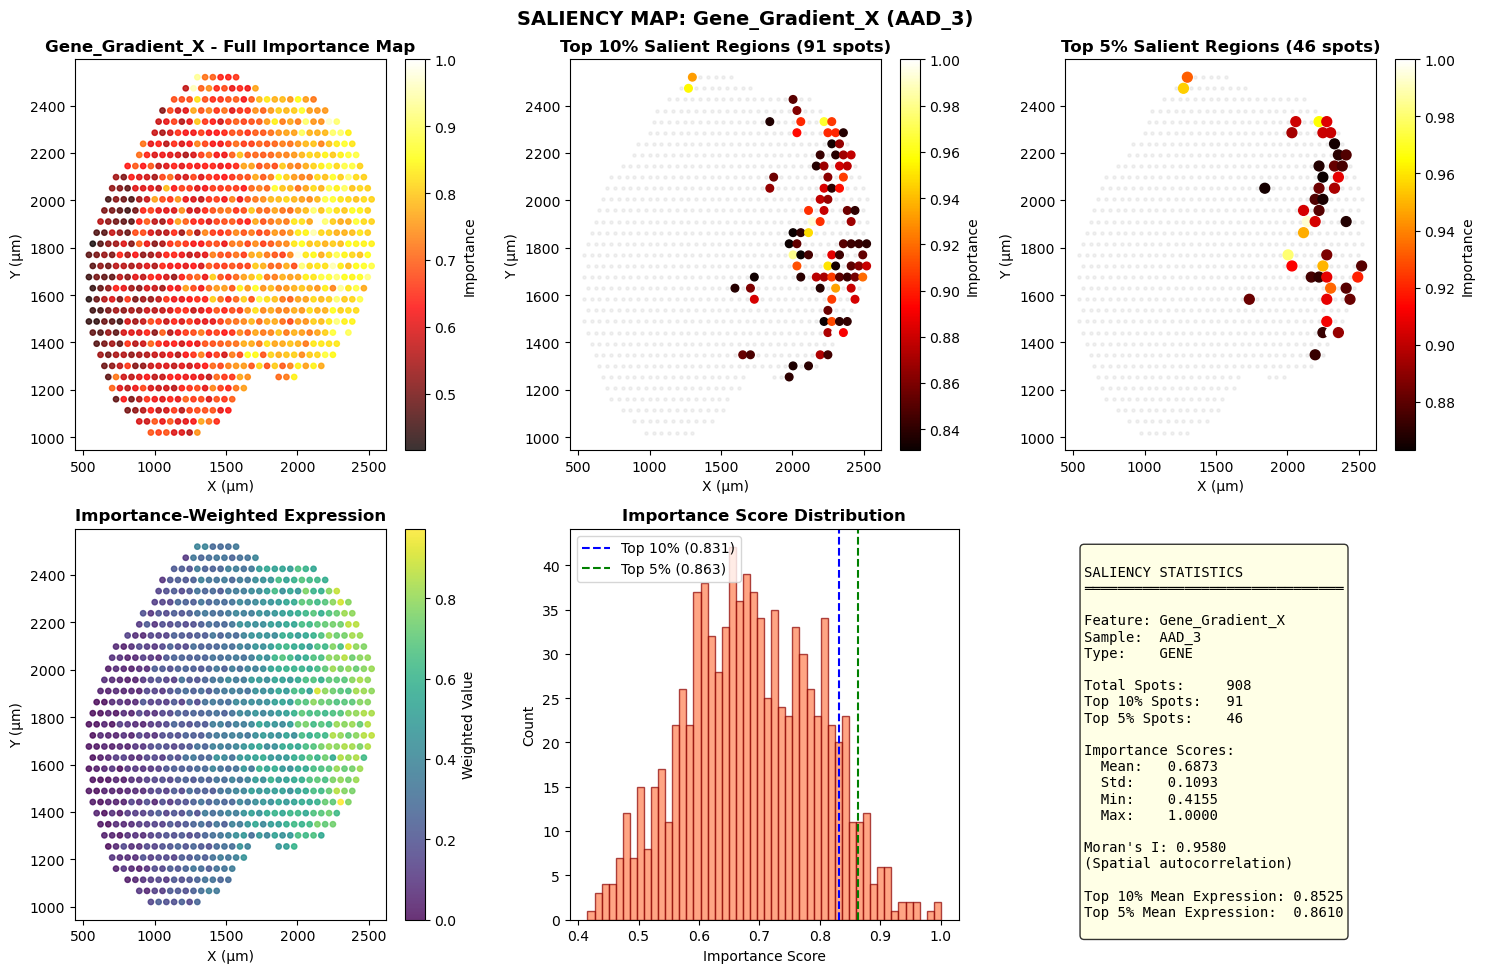

In [ ]:

def main():
    print("="*70)
    print("V10: Hybrid Matching with Cross-Modal Transformers")
    print(f"RNA: {RNA_PIXEL_SIZE}μm | MSI: {MSI_PIXEL_SIZE}μm")
    print(f"GNN Architecture: {'GATv2' if USE_GATV2 else 'GAT'}")
    print("="*70)
    
    matcher = HybridTransformerMatcher(output_dir='./test_gene_to_mz_results_v11')
    matcher.load_all_data()
    results = matcher.run_analysis(epochs_gnn=300, epochs_transformer=200, top_k=20)
    
    print("\n" + "="*70)
    print("COMPLETE!")
    print("="*70)
    
    return matcher, results


if __name__ == "__main__":
    matcher, results = main()